In [87]:
! pip install yfinance > /dev/null 2>&1
! mkdir hist
! pip install catboost

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
import yfinance as yf
import contextlib
import kagglehub
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GridSearchCV, KFold, train_test_split, TimeSeriesSplit
from sklearn.metrics import r2_score, accuracy_score



mkdir: cannot create directory ‘hist’: File exists


In [88]:

# # Download latest version
path_kaggle = kagglehub.dataset_download("jacksoncrow/stock-market-dataset")

print("Path to dataset files:", path_kaggle)

Using Colab cache for faster access to the 'stock-market-dataset' dataset.
Path to dataset files: /kaggle/input/stock-market-dataset


In [89]:
offset = 0
limit = 3000
period = 'max'

In [90]:
data = pd.read_csv("http://www.nasdaqtrader.com/dynamic/SymDir/nasdaqtraded.txt", sep='|')
data_clean = data[data['Test Issue'] == 'N']
symbols = data_clean['NASDAQ Symbol'].tolist()
print('total number of symbols traded = {}'.format(len(symbols)))

total number of symbols traded = 12076


The dataset contains stocks and ETFs - we want to specifically look at ETFs

In [91]:
path_kaggle = path_kaggle + '/etfs'
all_etfs = glob.glob(os.path.join(path_kaggle, "*.csv"))
print(all_etfs)

all_etf_symbols_csv = [path[40:] for path in all_etfs]
all_etf_symbols = [csv[:-4] for csv in all_etf_symbols_csv]
print(all_etf_symbols)

# # !Uncomment to view data in each csv
# # Loop through each file and print data
# for file in all_files:
#     df = pd.read_csv(file)
#     print(f"Processing: {file}")
#     # Perform your operations on df here
#     print(df.head())  # Example: print first 5 rows


['/kaggle/input/stock-market-dataset/etfs/LVHE.csv', '/kaggle/input/stock-market-dataset/etfs/HAUZ.csv', '/kaggle/input/stock-market-dataset/etfs/HDIV.csv', '/kaggle/input/stock-market-dataset/etfs/NETL.csv', '/kaggle/input/stock-market-dataset/etfs/HYDB.csv', '/kaggle/input/stock-market-dataset/etfs/XPP.csv', '/kaggle/input/stock-market-dataset/etfs/SPGP.csv', '/kaggle/input/stock-market-dataset/etfs/INTF.csv', '/kaggle/input/stock-market-dataset/etfs/SPBO.csv', '/kaggle/input/stock-market-dataset/etfs/PLW.csv', '/kaggle/input/stock-market-dataset/etfs/XES.csv', '/kaggle/input/stock-market-dataset/etfs/FGM.csv', '/kaggle/input/stock-market-dataset/etfs/TLT.csv', '/kaggle/input/stock-market-dataset/etfs/IYW.csv', '/kaggle/input/stock-market-dataset/etfs/FVC.csv', '/kaggle/input/stock-market-dataset/etfs/CLTL.csv', '/kaggle/input/stock-market-dataset/etfs/BGRN.csv', '/kaggle/input/stock-market-dataset/etfs/GVI.csv', '/kaggle/input/stock-market-dataset/etfs/FXD.csv', '/kaggle/input/stock

## We want the most up to date version of this dataset
> Uncomment the following cell if you want to get the most up to date version of the data


In [92]:
# %%time

# limit = limit if limit else len(symbols)
# end = min(offset + limit, len(symbols))
# is_valid = [False] * len(symbols)
# # force silencing of verbose API
# with open(os.devnull, 'w') as devnull:
#     with contextlib.redirect_stdout(devnull):
#         for i in range(offset, end):
#             s = symbols[i]
#             if s not in all_etf_symbols:
#                 continue
#             try:
#               data = yf.download(s, period=period)
#               if len(data.index) == 0:
#                   continue

#               is_valid[i] = True
#               data.to_csv('hist/{}.csv'.format(s))
#             except:
#               print('Download failed:')
#               is_valid[i] = False

# print('Total number of valid symbols downloaded = {}'.format(sum(is_valid)))

## Find one file with most data, not including columns that are 0
> Uncomment the following cell if you want to run the process of finding which file to use

In [93]:
# max_rows = 0
# max_df = None
# max_file = None

# path_to_downloads = ['/content/hist/'+symbol_csv for symbol_csv in all_etf_symbols_csv]

# for file in path_to_downloads:
#   if os.path.exists(file):
#     df = pd.read_csv(file)
#     df = df[df['Open'] != 0] #remove lines where open == 0
#     # df = df.drop(columns=['Date']) #drops the date column completely, will deal with this later
#     if len(df) > max_rows:
#       max_rows = len(df)
#       max_df = df
#       max_file = file
# print("Data Frame: \n" , max_df.head(), "\nRows: " , max_rows, "\nFile: " , max_file)



> Results: File:  /content/hist/CEF.csv




## Download and read in the dataset


In [94]:
with open(os.devnull, 'w') as devnull:
    with contextlib.redirect_stdout(devnull):
      s = 'CEF'
      try:
        data = yf.download(s, period=period)

        data.to_csv('hist/{}.csv'.format(s))
      except:
        print('Download failed:')

df = pd.read_csv('/content/hist/CEF.csv')


/tmp/ipython-input-3027740980.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(s, period=period)
[*********************100%***********************]  1 of 1 completed


In [95]:
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,CEF,CEF,CEF,CEF,CEF
1,Date,NaN,NaN,NaN,NaN,NaN
2,1986-04-03,4.4495530128479,4.56981120238433,4.4495530128479,4.4495530128479,15300
3,1986-04-04,4.569809913635254,4.569809913635254,4.5096808358242635,4.5096808358242635,12000
4,1986-04-07,4.569809913635254,4.690068069257234,4.569809913635254,4.569809913635254,11500


## Clean data to correctly format



In [96]:
# convert prices to % returns to see how much price changed from yesterday

# Correcting the DataFrame structure first due to incorrect read_csv parsing.
# Based on the df.head() output, the actual data starts from the third row (index 2).
# The first column contains the Date, which should be the index.
df = df.iloc[2:].copy()

# Rename the first column to 'Date' and set it as the index
df.rename(columns={'Price': 'Date'}, inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Convert relevant columns to numeric, coercing errors will turn non-convertible values into NaN
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop any rows that might have become entirely NaN after coercion or were bad data
df.dropna(inplace=True)


## Include price changes as columns

In [98]:
df['Open_Pct']   = df['Open'].pct_change()
df['High_Pct']   = df['High'].pct_change()
df['Low_Pct']    = df['Low'].pct_change()
df['Close_Pct']  = df['Close'].pct_change()
df['Volume_Pct'] = df['Volume'].pct_change()

# Catboost stuff below


In [99]:

# predict next day's close return by shifting column up by 1
# this means: use today's data (row i) to predict tomorrow's return (row i+1)
df['Target_Next_Day_Return'] = df['Close_Pct'].shift(-1)
df = df.dropna() # remove bad columns

# 5. Define X and y using the NEW features
features = ['Open_Pct', 'High_Pct', 'Low_Pct', 'Close_Pct', 'Volume_Pct']
X = df[features]
y = df['Target_Next_Day_Return']

#this splits the data for train and test
#shuffle = false make its chronological where train is older than test
#shuffle = true makes it random
#not sure which to choose since having it random leads to data leakage / memorization between open and closes between days
#but leaving it chronological means if the stock goes up and the train data was never tested with numbers that high itll max out and have a really bad r2 score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, shuffle=True)

print("starting best parameter search")

param_grid = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

base_model = CatBoostRegressor(
    iterations = 500,
    loss_function = 'RMSE',
    random_seed = 96594,
    verbose = 0,
    allow_writing_files = False
)

grid_search = GridSearchCV(
    estimator = base_model,
    param_grid = param_grid,
    #cv = TimeSeriesSplit(n_splits=3), #chronological splits
    cv = 3, #random splits
    scoring = 'r2',
    n_jobs = -1
)

grid_search.fit(X_train, y_train)

print(f"best r2 score: {grid_search.best_score_:.4f}")
print("best parameters found:", grid_search.best_params_)

best_model = grid_search.best_estimator_

importance = best_model.get_feature_importance()
feature_names = X_train.columns
importance_df = pd.DataFrame({'feature': feature_names, 'score': importance})

importance_df = importance_df.sort_values(by='score', ascending=False)
print(importance_df)

low_impact_features = importance_df[importance_df['score'] < 5.0]['feature'].tolist()
print(f"dropping {len(low_impact_features)} features: {low_impact_features}")

X_train_reduced = X_train.drop(columns=low_impact_features)
X_test_reduced = X_test.drop(columns=low_impact_features)

starting best parameter search
best r2 score: 0.0070
best parameters found: {'depth': 4, 'l2_leaf_reg': 5, 'learning_rate': 0.01}
      feature      score
3   Close_Pct  41.530209
2     Low_Pct  17.844819
0    Open_Pct  15.219219
4  Volume_Pct  13.972718
1    High_Pct  11.433035
dropping 0 features: []


In [100]:

print("training best model on full reduced dataset")
best_model.fit(X_train_reduced, y_train)
y_pred = best_model.predict(X_test_reduced)

score = r2_score(y_test, y_pred)
print("test R2 Score:", score)

training best model on full reduced dataset
test R2 Score: 0.016726967389407377


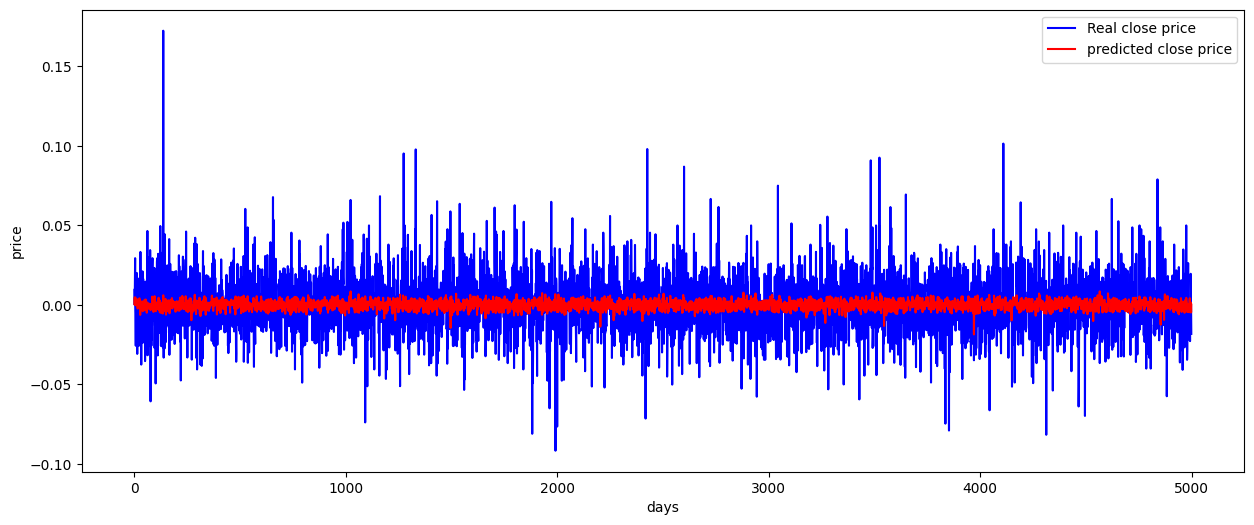

In [101]:

#plots y_pred vs y_test
plt.figure(figsize=(15, 6))
plt.plot(y_test.values, label='Real close price', color='blue')
plt.plot(y_pred, label='predicted close price', color='red')
plt.xlabel("days")
plt.ylabel("price")
plt.legend()
plt.show()